In [1]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
airbnb_practica = pd.read_csv("airbnb-listings-extract.csv", engine='python', sep=None) #Con este código cargamos el fichero CSV
airbnb_practica.head(8)
#Hago una primera exploración de toda la base de datos y veo que hay muchas celdas que quizás, no aporten valor a la hora de predecir el precio. 


,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,11210388,https://www.airbnb.com/rooms/11210388,20170306202425,2017-03-07,The Loft-Full Bath-Deck w/View,Loft in the Hill country 12-15 minutes directl...,This loft has a spectacular view of the hills ...,Loft in the Hill country 12-15 minutes directl...,none,This neighborhood is located in the hills west...,...,10.0,10.0,10.0,NaN,NaN,moderate,1.0,3.50,"30.3373609355,-97.8632766782","Host Is Superhost,Host Has Profile Pic,Host Id..."
1,17471131,https://www.airbnb.com/rooms/17471131,20170407214050,2017-04-08,"Claris I, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,10.0,8.0,10.0,HUTB-006721,NaN,super_strict_30,106.0,0.86,"41.3896829422,2.17262543017","Host Has Profile Pic,Requires License,Instant ..."
2,17584891,https://www.airbnb.com/rooms/17584891,20170407214050,2017-04-08,"Style Terrace Red, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,NaN,NaN,NaN,HUTB-007527,NaN,super_strict_30,106.0,NaN,"41.3930345489,2.16217327868","Host Has Profile Pic,Requires License,Instant ..."
3,5398030,https://www.airbnb.com/rooms/5398030,20170407214050,2017-04-08,Picasso Suite 1.4 Paseo de Gracia,Live like a local in Barcelona's most chic dis...,You wake up to the sun rising over Barcelona's...,Live like a local in Barcelona's most chic dis...,none,We're right in the heart of the chic L'Eixampl...,...,10.0,10.0,9.0,NaN,NaN,strict,24.0,1.09,"41.3969668101,2.1674178103","Host Has Profile Pic,Host Identity Verified,Re..."
4,18104606,https://www.airbnb.com/rooms/18104606,20170407214050,2017-04-08,Smart City Centre Apartment II,"Unique apartment in vibrant neighborhoods, car...","License: HUTB-005313 Charming apartment, locat...","Unique apartment in vibrant neighborhoods, car...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,92.0,NaN,"41.3886851936,2.15514963616","Host Has Profile Pic,Host Identity Verified,Is..."
5,15695269,https://www.airbnb.com/rooms/15695269,20170407214050,2017-04-08,55. Valencia II Apartment,"Unique apartment in vibrant neighborhoods, car...",This fully refurbished apartment has 2 bedroom...,"Unique apartment in vibrant neighborhoods, car...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,strict,92.0,NaN,"41.3825366724,2.14957707323","Host Has Profile Pic,Host Identity Verified,Is..."
6,1295958,https://www.airbnb.com/rooms/1295958,20170407214050,2017-04-08,3 BR + 2 baths near the beach!!,Spacious and quiet apartment that can accommod...,Its size allows to accommodate up to 6 people ...,Spacious and quiet apartment that can accommod...,none,"This unique area is rich in history, architect...",...,10.0,9.0,9.0,HUTB-0077039-0,NaN,strict,1.0,1.22,"41.3990576554,2.18422942312","Host Has Profile Pic,Is Location Exact,Require..."
7,1349311,https://www.airbnb.com/rooms/1349311,20170407214050,2017-04-08,Room & bathroom @ Sagrada Familia,"FEBRUARY 6-10, entire apartment available - 2 ...",Our apartment has been recently renovated pres...,"FEBRUARY 6-10, entire apartment available - 2 ...",none,I love arriving home from work and suddenly se...,...,10.0,10.0,10.0,NaN,NaN,flexible,1.0,0.64,"41.4023570187,2.17111908017","Host Has Profile Pic,Is Location Exact,Require..."


In [3]:
airbnb_practica.columns

Index(['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary',
       'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview',
       'Notes', 'Transit', 'Access', 'Interaction', 'House Rules',
       'Thumbnail Url', 'Medium Url', 'Picture Url', 'XL Picture Url',
       'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location',
       'Host About', 'Host Response Time', 'Host Response Rate',
       'Host Acceptance Rate', 'Host Thumbnail Url', 'Host Picture Url',
       'Host Neighbourhood', 'Host Listings Count',
       'Host Total Listings Count', 'Host Verifications', 'Street',
       'Neighbourhood', 'Neighbourhood Cleansed',
       'Neighbourhood Group Cleansed', 'City', 'State', 'Zipcode', 'Market',
       'Smart Location', 'Country Code', 'Country', 'Latitude', 'Longitude',
       'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Bedrooms',
       'Beds', 'Bed Type', 'Amenities', 'Square Feet', 'Price', 'Weekly Price',
       'Month

In [4]:
def categorizar(amenit):
    if pd.isna(amenit):
        return 0
    return int("Air conditioning" in amenit and "Pool" in amenit)
airbnb_practica['Amenities'] = airbnb_practica['Amenities'].apply(categorizar)

In [5]:
columnas_ok_practica = ['Neighbourhood Cleansed','City', 'Country', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Price', 'Security Deposit', 'Cleaning Fee',
                         'Guests Included','Extra People', 'Amenities', 'Availability 365', 'Review Scores Rating']
airbnb_practica_v2 = airbnb_practica[columnas_ok_practica]
airbnb_practica_v2.head(35)

# 1_Ponemos en primer lugar a Price por comodidad
cols = ['Price'] + [col for col in airbnb_practica_v2.columns if col != 'Price']
airbnb_practica_v2 = airbnb_practica_v2[cols]
airbnb_practica_v2.head(10)

# Anteriormente, había más columnas sin embargo, al realizar una matriz de correlación y hacer una exploración de datos,
# vi que tanto Beds como Bedrooms se podían eliminar al estar muy correlacionadas con Accommodates y solo quedarme con Review
# Score rating (el agregado de todas las reviews y Reviews per Month)

,Price,Neighbourhood Cleansed,City,Country,Property Type,Room Type,Accommodates,Bathrooms,Security Deposit,Cleaning Fee,Guests Included,Extra People,Amenities,Availability 365,Review Scores Rating
0,58.0,78733,Austin,United States,Loft,Entire home/apt,2,1.0,100.0,NaN,1,0,1,281,98.0
1,70.0,la Dreta de l'Eixample,Barcelona,Spain,Apartment,Entire home/apt,4,1.0,200.0,40.0,2,44,0,309,80.0
2,70.0,la Dreta de l'Eixample,Barcelona,Spain,Apartment,Entire home/apt,4,1.0,200.0,60.0,2,42,0,291,NaN
3,229.0,la Dreta de l'Eixample,Barcelona,Spain,Apartment,Entire home/apt,8,2.0,250.0,79.0,2,39,0,316,92.0
4,149.0,l'Antiga Esquerra de l'Eixample,Barcelona,Spain,Apartment,Entire home/apt,5,1.0,NaN,55.0,1,0,0,7,NaN
5,106.0,la Nova Esquerra de l'Eixample,Barcelona,Spain,Apartment,Entire home/apt,6,1.0,NaN,NaN,1,0,0,4,NaN
6,52.0,el Fort Pienc,Barcelona,Spain,Apartment,Entire home/apt,5,2.0,300.0,60.0,4,25,0,280,90.0
7,45.0,la Sagrada Família,Barcelona,Spain,Apartment,Private room,2,1.0,300.0,30.0,1,20,0,66,96.0
8,80.0,el Camp de l'Arpa del Clot,Barcelona,Spain,Apartment,Entire home/apt,6,2.0,NaN,NaN,1,0,0,2,80.0
9,795.0,78703,Austin,United States,House,Entire home/apt,6,2.0,NaN,250.0,1,0,0,356,100.0


In [6]:
# 1_Hacemos la división train / test:
from sklearn.model_selection import train_test_split
train, test = train_test_split(airbnb_practica_v2, test_size=0.2, shuffle=True, random_state=0) 

# 2_Creamos los CSV train y test para trabajarlos posteriormente:
train.to_csv("airbnb_practica_train.csv", sep=';', decimal='.', index=False)
test.to_csv("airbnb_practica_test.csv", sep=';', decimal='.', index=False)

# 3_Pintamos sus dimensiones:
print(f'Dimensiones del dataset de training: {train.shape}')
print(f'Dimensiones del dataset de test: {test.shape}')

# 4_Cargamos el csv de train y hacemos el análisis exploratorio con él
airbnb_practica_train = pd.read_csv("airbnb_practica_train.csv", engine='python', sep=None)
airbnb_practica_test = pd.read_csv("airbnb_practica_test.csv", engine='python', sep=None)



Dimensiones del dataset de training: (11824, 15)
Dimensiones del dataset de test: (2956, 15)


In [7]:
airbnb_practica_train.isnull().any()
# Aquí vemos como hay bastantes columnas con valores nulos. 

Price                      True
Neighbourhood Cleansed    False
City                       True
Country                    True
Property Type             False
Room Type                 False
Accommodates              False
Bathrooms                  True
Security Deposit           True
Cleaning Fee               True
Guests Included           False
Extra People              False
Amenities                 False
Availability 365          False
Review Scores Rating       True
dtype: bool

In [8]:
airbnb_practica_train.head(40)
# Los valores de Bathrooms, Bedrooms, Beds, Security Deposit, Cleaning Fee
# Los valores de Review Scores rating, Review Scores Accuracy, Review Scores Cleanlinessy Review Scores Location 
from sklearn.impute import KNNImputer
columnas_imputacion = ["Bathrooms","Price","Security Deposit", "Cleaning Fee", "Review Scores Rating"]
imputer = KNNImputer(n_neighbors=15)
airbnb_practica_train[columnas_imputacion] = imputer.fit_transform(airbnb_practica_train[columnas_imputacion])

In [9]:
madrid_aliases = ['马德里', 'Мадрид', 'Madrид'] 
airbnb_practica_train['City'] = airbnb_practica_train['City'].replace(madrid_aliases, 'Madrid')

In [10]:
columnas_imputacion_2 = ['City', 'Country']
airbnb_practica_train[columnas_imputacion_2] = airbnb_practica_train[columnas_imputacion_2].fillna("Desconocido")
print(airbnb_practica_train[columnas_imputacion_2].isnull().sum())

City       0
Country    0
dtype: int64


In [11]:
print(airbnb_practica_train.isnull().any())

Price                     False
Neighbourhood Cleansed    False
City                      False
Country                   False
Property Type             False
Room Type                 False
Accommodates              False
Bathrooms                 False
Security Deposit          False
Cleaning Fee              False
Guests Included           False
Extra People              False
Amenities                 False
Availability 365          False
Review Scores Rating      False
dtype: bool


In [12]:
airbnb_practica_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11824 entries, 0 to 11823
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   11824 non-null  float64
 1   Neighbourhood Cleansed  11824 non-null  object 
 2   City                    11824 non-null  object 
 3   Country                 11824 non-null  object 
 4   Property Type           11824 non-null  object 
 5   Room Type               11824 non-null  object 
 6   Accommodates            11824 non-null  int64  
 7   Bathrooms               11824 non-null  float64
 8   Security Deposit        11824 non-null  float64
 9   Cleaning Fee            11824 non-null  float64
 10  Guests Included         11824 non-null  int64  
 11  Extra People            11824 non-null  int64  
 12  Amenities               11824 non-null  int64  
 13  Availability 365        11824 non-null  int64  
 14  Review Scores Rating    11824 non-null

In [13]:
from sklearn.preprocessing import TargetEncoder
cat_cols = ['Neighbourhood Cleansed', 'City', 'Country', 'Property Type', 'Room Type']
target_encoder = TargetEncoder(smooth="auto", target_type="continuous")
airbnb_practica_train[cat_cols] = target_encoder.fit_transform(airbnb_practica_train[cat_cols], airbnb_practica_train['Price'])

In [14]:
airbnb_practica_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11824 entries, 0 to 11823
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   11824 non-null  float64
 1   Neighbourhood Cleansed  11824 non-null  float64
 2   City                    11824 non-null  float64
 3   Country                 11824 non-null  float64
 4   Property Type           11824 non-null  float64
 5   Room Type               11824 non-null  float64
 6   Accommodates            11824 non-null  int64  
 7   Bathrooms               11824 non-null  float64
 8   Security Deposit        11824 non-null  float64
 9   Cleaning Fee            11824 non-null  float64
 10  Guests Included         11824 non-null  int64  
 11  Extra People            11824 non-null  int64  
 12  Amenities               11824 non-null  int64  
 13  Availability 365        11824 non-null  int64  
 14  Review Scores Rating    11824 non-null

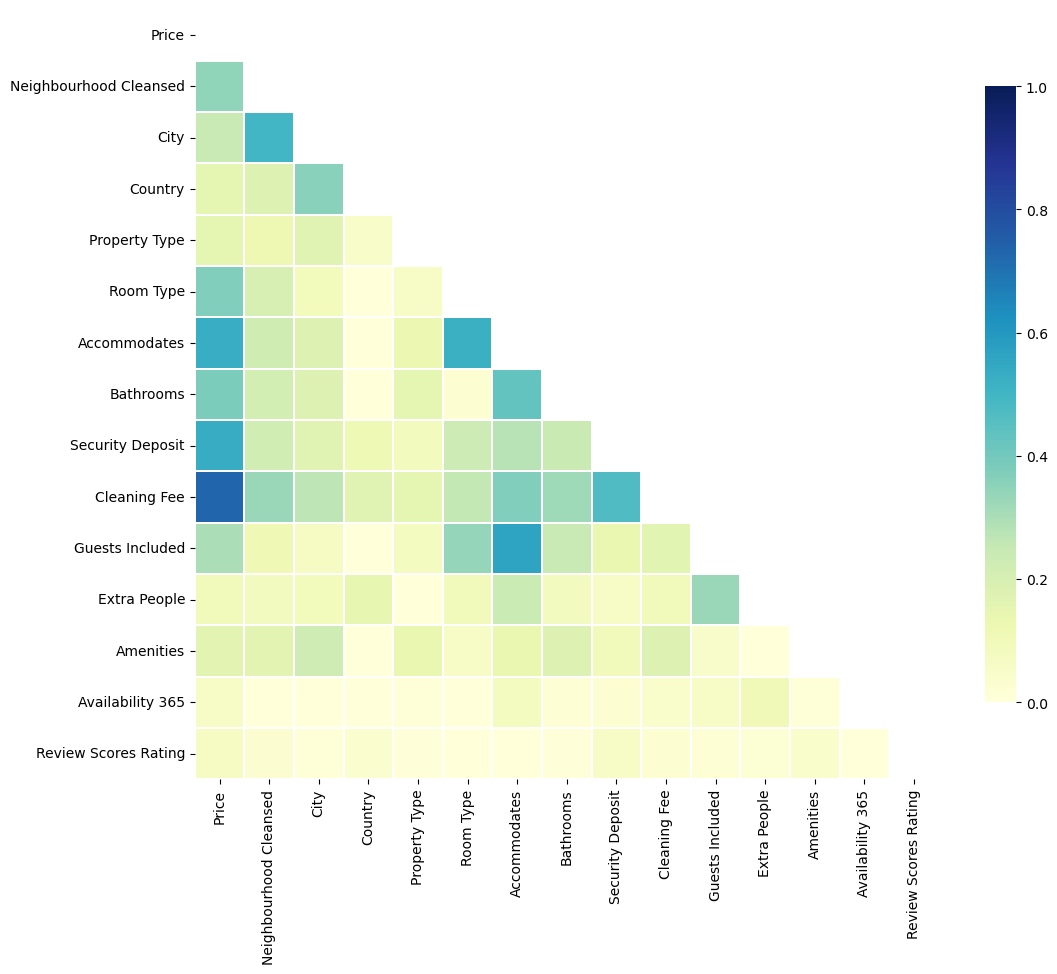

In [15]:
import seaborn as sns

# Compute the correlation matrix
corr = np.abs(airbnb_practica_train).corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(12, 10))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()
#De este dibujo, podemos obtener que las variables que están más correlacionadas con el precio son: Beds, Bedrooms, 

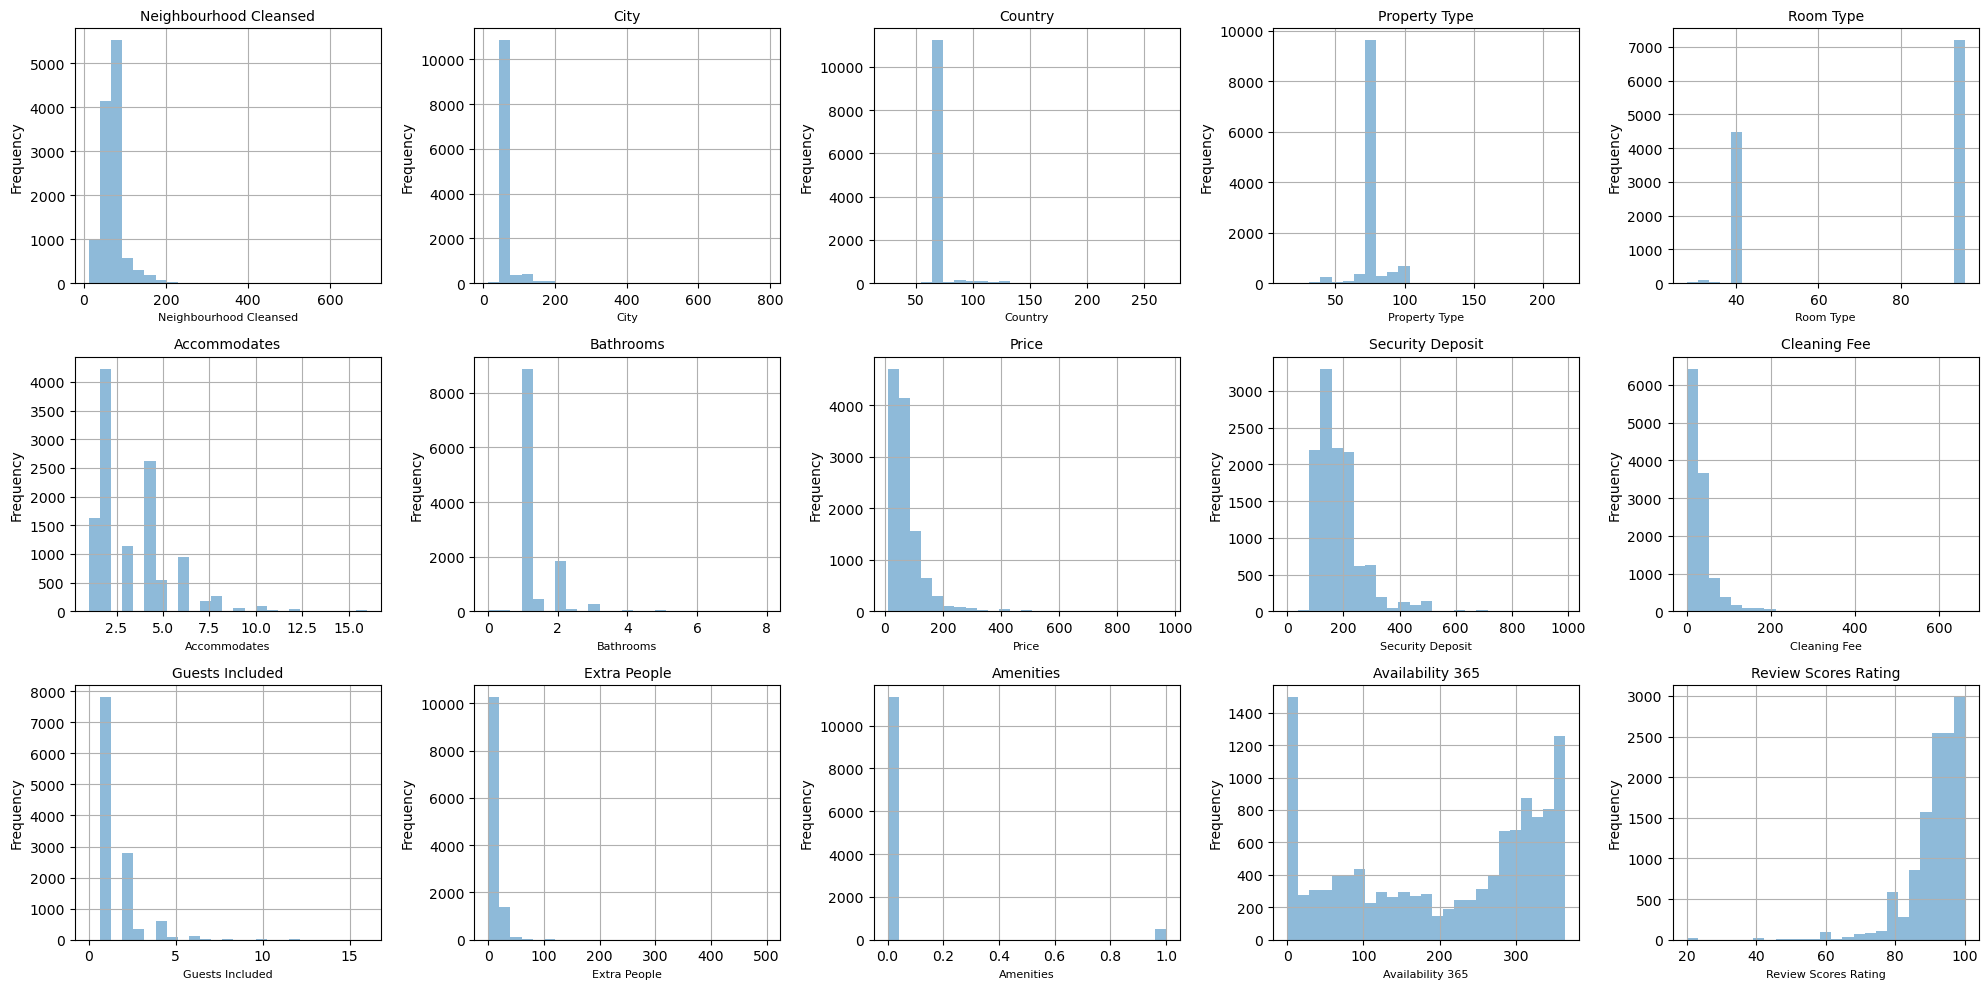

In [16]:
columnas_ok_practica_numericas = ['Neighbourhood Cleansed','City', 'Country', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Price', 'Security Deposit', 'Cleaning Fee',
                         'Guests Included','Extra People', 'Amenities', 'Availability 365', 'Review Scores Rating']

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(columnas_ok_practica_numericas):
    airbnb_practica_train[feature].plot.hist(ax=axes[i], alpha=0.5, bins=25, grid=True)
    axes[i].set_xlabel(feature, fontsize=8)
    axes[i].set_title(feature, fontsize=10)

plt.tight_layout()
plt.show()

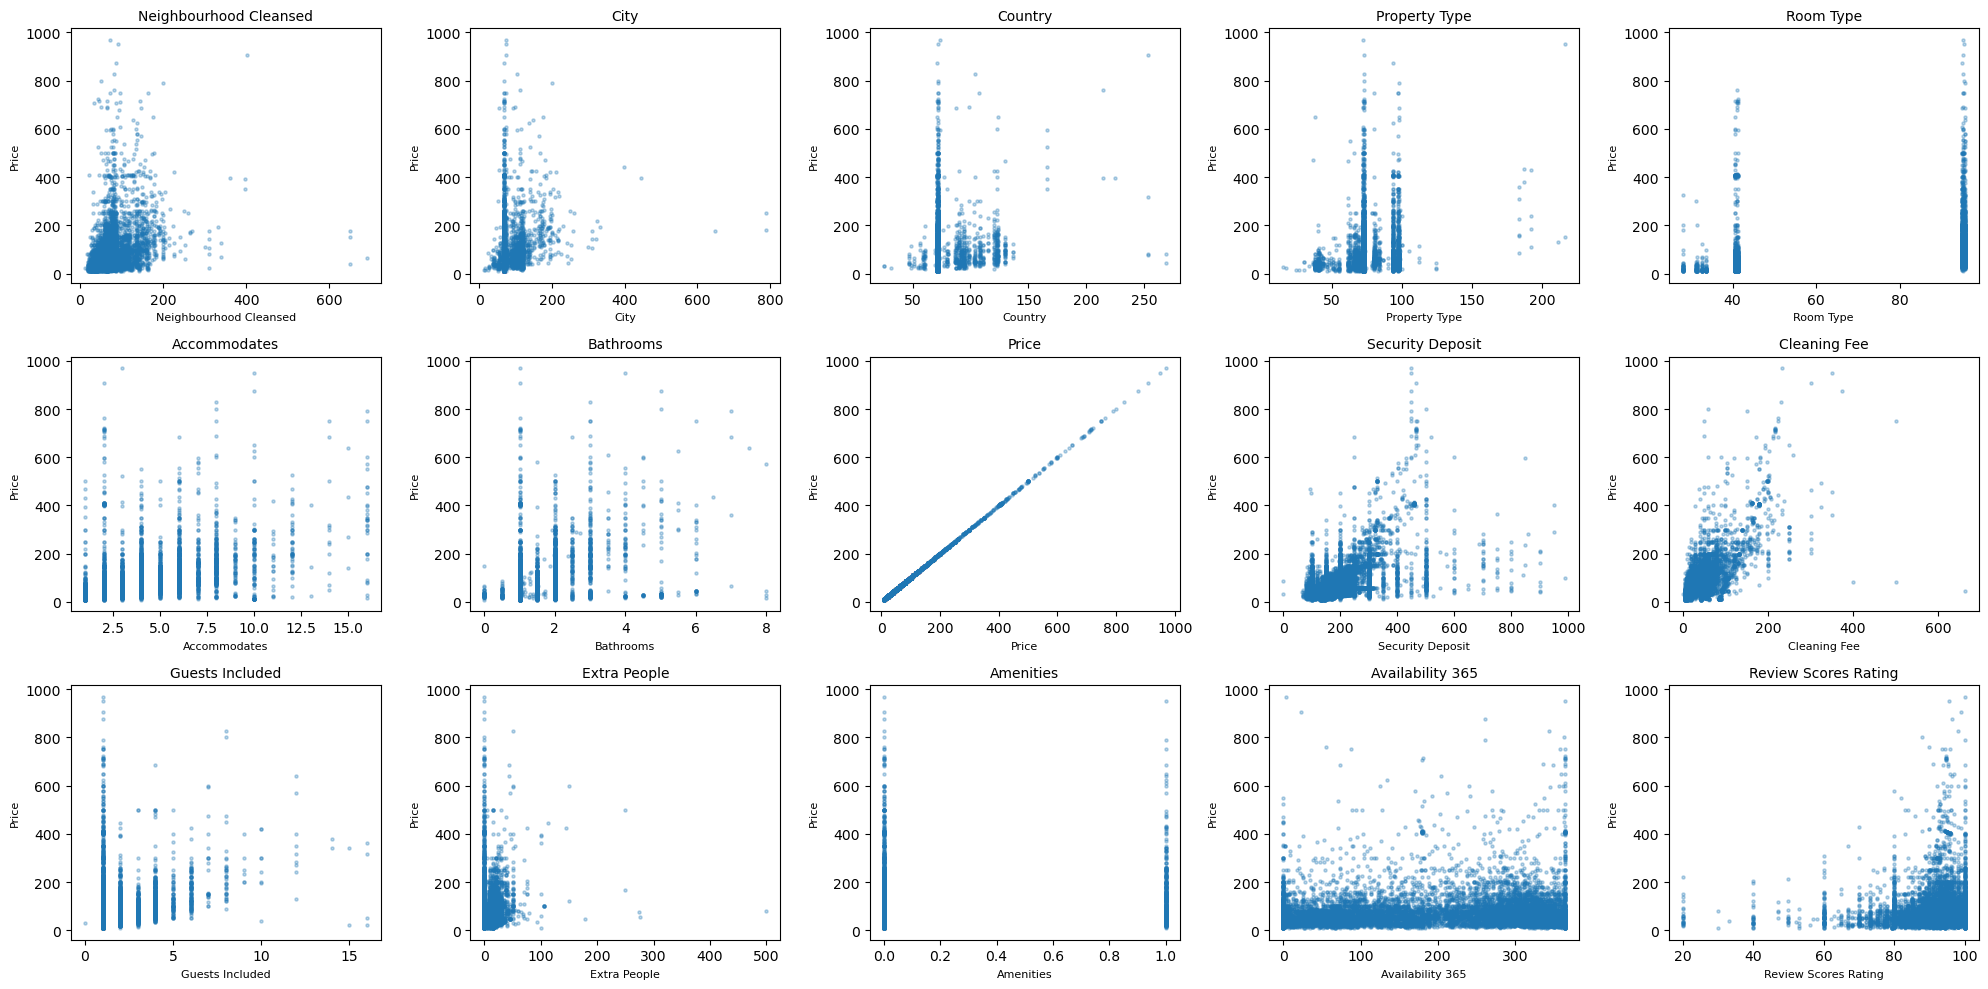

In [17]:
columnas_ok_practica_numericas = ['Neighbourhood Cleansed','City', 'Country', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Price', 'Security Deposit', 'Cleaning Fee',
                         'Guests Included','Extra People', 'Amenities', 'Availability 365', 'Review Scores Rating']

plt.figure(figsize=(20, 10))

for i, feature in enumerate(columnas_ok_practica_numericas):
    plt.subplot(3, 5, i+1)
    plt.scatter(airbnb_practica_train[feature], 
                airbnb_practica_train['Price'], 
                alpha=0.3, s=5)
    plt.xlabel(feature, fontsize=8)
    plt.ylabel('Price', fontsize=8)
    plt.title(feature, fontsize=10)

plt.tight_layout()
plt.show()


In [18]:
airbnb_practica_train_no_outliers = airbnb_practica_train[airbnb_practica_train['Cleaning Fee'] <= 300]
airbnb_practica_train_no_outliers2 = airbnb_practica_train_no_outliers[airbnb_practica_train_no_outliers['Extra People'] <= 120]
airbnb_practica_train_no_outliers3 = airbnb_practica_train_no_outliers2[airbnb_practica_train_no_outliers2['Security Deposit'] <= 900]
airbnb_practica_train_no_outliers4 = airbnb_practica_train_no_outliers3[airbnb_practica_train_no_outliers3['Bathrooms'] <= 7]
airbnb_practica_train_no_outliers5 = airbnb_practica_train_no_outliers4[airbnb_practica_train_no_outliers4['City'] <= 300]
airbnb_practica_train_no_outliers6 = airbnb_practica_train_no_outliers5[airbnb_practica_train_no_outliers5['Neighbourhood Cleansed'] <= 275]
airbnb_practica_train_final = airbnb_practica_train_no_outliers6[airbnb_practica_train_no_outliers6['Country'] <= 175]

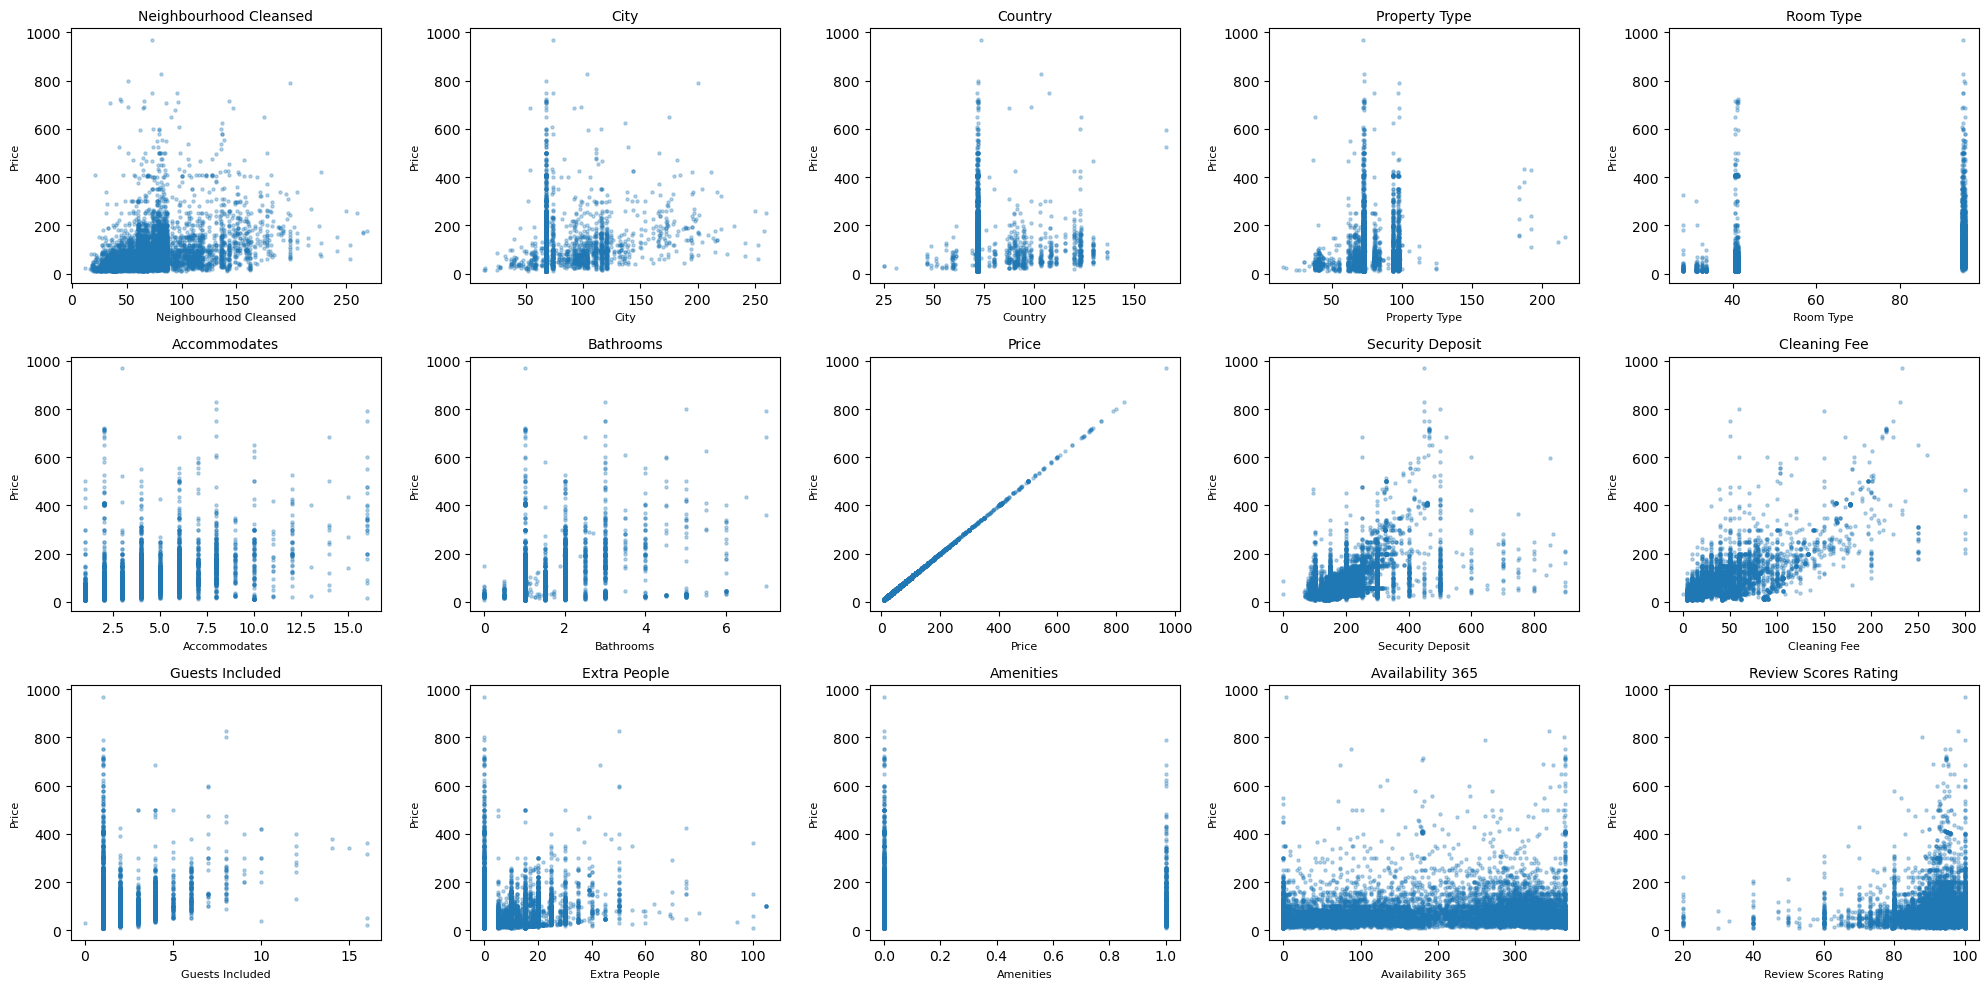

In [19]:
columnas_ok_practica_numericas = ['Neighbourhood Cleansed','City', 'Country', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Price', 'Security Deposit', 'Cleaning Fee',
                         'Guests Included','Extra People', 'Amenities', 'Availability 365', 'Review Scores Rating']

plt.figure(figsize=(20, 10))

for i, feature in enumerate(columnas_ok_practica_numericas):
    plt.subplot(3, 5, i+1)
    plt.scatter(airbnb_practica_train_final[feature], 
                airbnb_practica_train_final['Price'], 
                alpha=0.3, s=5)
    plt.xlabel(feature, fontsize=8)
    plt.ylabel('Price', fontsize=8)
    plt.title(feature, fontsize=10)

plt.tight_layout()
plt.show()

c:\Users\Usuario\Searches\Nueva carpeta\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Usuario\Searches\Nueva carpeta\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


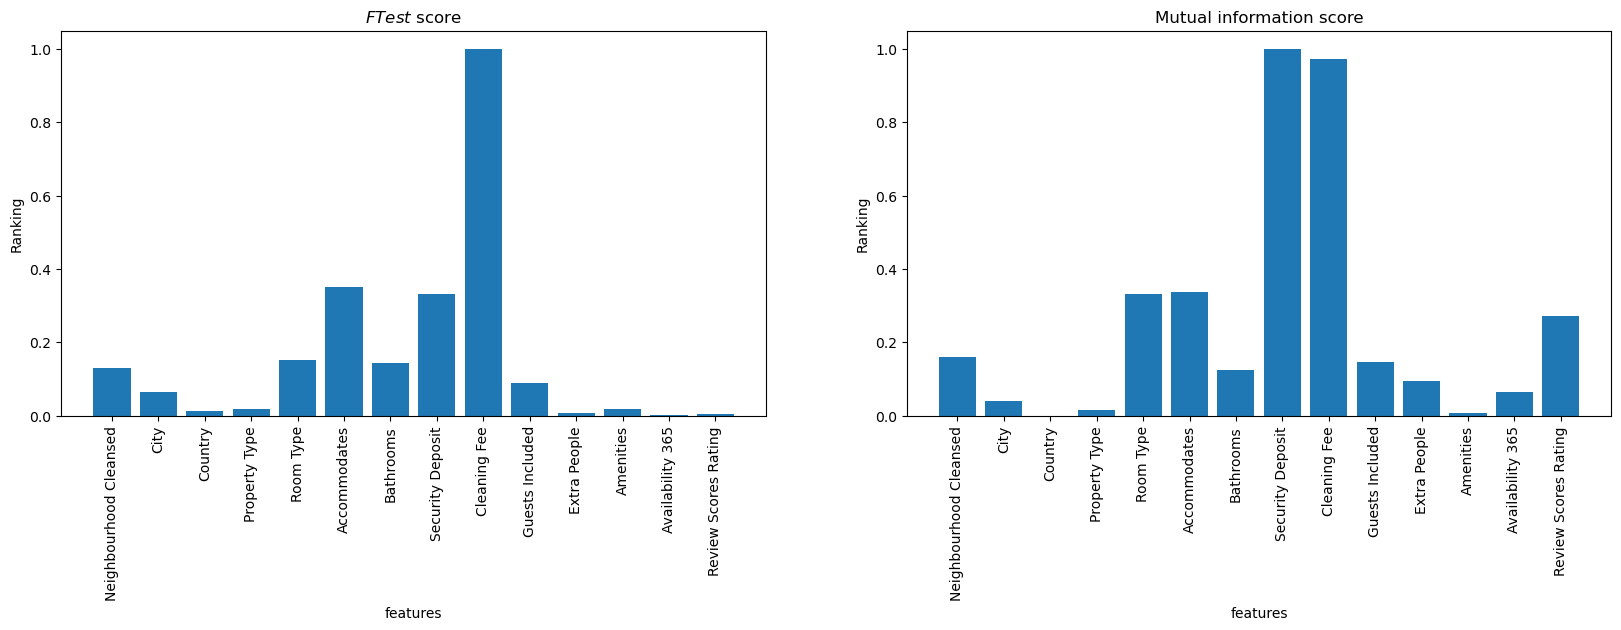

In [20]:
import seaborn as sns
from sklearn.feature_selection import f_regression, mutual_info_regression
data = airbnb_practica_train_final.values

y = data[:,0:1]     # nos quedamos con la 1ª columna, price
X = data[:,1:] 

feature_names = airbnb_practica_train_final.columns[1:]

# estudiamos los dos métodos de filtrado
f_test, _ = f_regression(X, y)
f_test /= np.max(f_test)

mi = mutual_info_regression(X, y)
mi /= np.max(mi)

# visualización
plt.figure(figsize=(20, 5))

plt.subplot(1,2,1)
plt.bar(range(X.shape[1]),f_test,  align="center")
plt.xticks(range(X.shape[1]),feature_names, rotation = 90)
plt.xlabel('features')
plt.ylabel('Ranking')
plt.title('$F Test$ score')

plt.subplot(1,2,2)
plt.bar(range(X.shape[1]),mi, align="center")
plt.xticks(range(X.shape[1]),feature_names, rotation = 90)
plt.xlabel('features')
plt.ylabel('Ranking')
plt.title('Mutual information score')

plt.show()

In [21]:
airbnb_practica_train.head(10)

,Price,Neighbourhood Cleansed,City,Country,Property Type,Room Type,Accommodates,Bathrooms,Security Deposit,Cleaning Fee,Guests Included,Extra People,Amenities,Availability 365,Review Scores Rating
0,60.0,103.773267,67.909611,71.951941,72.548408,95.105007,4,1.0,222.266667,25.000000,1,0,0,117,95.000000
1,50.0,86.738511,67.909611,71.951941,72.548408,95.105007,4,1.0,218.000000,15.000000,1,0,0,208,91.000000
2,10.0,37.277741,67.832310,71.951985,72.467723,31.402793,1,1.5,131.600000,5.000000,1,0,0,140,96.733333
3,30.0,60.570296,68.089112,72.189096,72.347410,41.384340,2,3.0,193.466667,27.666667,1,0,0,311,93.066667
4,32.0,58.143947,68.089112,72.189096,72.347410,41.384340,2,1.0,170.666667,18.066667,1,10,0,337,92.000000
5,35.0,60.218486,67.685187,71.700418,71.879817,40.449035,1,1.0,184.400000,25.066667,1,0,0,356,97.000000
6,80.0,77.801476,67.832310,71.951985,72.467723,95.468949,4,1.0,300.000000,18.000000,2,21,0,75,98.000000
7,25.0,83.149288,67.368483,71.413203,72.240423,40.594146,2,3.0,147.333333,14.000000,1,5,0,74,85.800000
8,69.0,97.358505,40.000000,71.413203,72.240423,94.893732,4,1.0,150.000000,45.000000,3,10,1,339,100.000000
9,158.0,83.982859,67.368483,71.413203,72.240423,94.893732,4,2.0,287.333333,160.000000,2,20,0,52,100.000000
